# Credit Score Classification - Machine Learning Project

**Author:** Davide De Blasio  
**Date:** November 19, 2025

---

## Project Overview

This project performs comprehensive data analysis and preprocessing on a credit score classification dataset. The workflow follows a systematic approach from data acquisition through to model-ready features, including:

- Exploratory Data Analysis (EDA)
- Data Cleaning & Missing Value Treatment
- Feature Engineering
- Statistical Testing & Feature Selection
- Outlier Detection & Treatment
- Feature Encoding
- Preprocessing for Machine Learning

**Target Variable:** Credit Score (Poor, Standard, Good)

---

# === 1. ENVIRONMENT SETUP ===

In [ ]:
# Dataset download
import kagglehub

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Statistical testing
from scipy import stats
import pingouin as pg

# Preprocessing and modeling
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

# === 2. DATA ACQUISITION ===

In [ ]:
# Download the dataset from Kaggle
path = kagglehub.dataset_download("parisrohan/credit-score-classification")

# Load the CSV files in data
df = pd.read_csv(path + "/train.csv", low_memory=False)

print(f"\nDataset Dimensions: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

# === 3. EXPLORATORY DATA ANALYSIS (EDA) ===

## 3.1 Dataset Overview

In [ ]:
# Data types
print("Data Types:")
print(df.dtypes)

In [ ]:
# Dataset information
df.info()

In [ ]:
# Unique values per column
print("Unique Values per Column:")
print(df.nunique())

In [ ]:
# Check for duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")

## 3.2 Feature Descriptions

**Key Features:**
- **ID**: Unique identification of an entry
- **Customer_ID**: Unique identification of a person
- **Month**: Month of the year
- **Name**: Name of a person
- **Age**: Age of the person
- **SSN**: Social security number
- **Occupation**: Occupation of the person
- **Annual_Income**: Annual income of the person
- **Monthly_Inhand_Salary**: Monthly base salary
- **Num_Bank_Accounts**: Number of bank accounts held
- **Num_Credit_Card**: Number of credit cards held
- **Interest_Rate**: Interest rate on credit card
- **Num_of_Loan**: Number of loans taken
- **Type_of_Loan**: Types of loans taken
- **Delay_from_due_date**: Average days delayed from payment date
- **Num_of_Delayed_Payment**: Average number of payments delayed
- **Changed_Credit_Limit**: Percentage change in credit card limit
- **Num_Credit_Inquiries**: Number of credit card inquiries
- **Credit_Mix**: Classification of mix of credits
- **Outstanding_Debt**: Remaining debt to be paid (USD)
- **Credit_Utilization_Ratio**: Utilization ratio of credit card
- **Credit_History_Age**: Age of credit history
- **Payment_of_Min_Amount**: Whether minimum amount was paid
- **Total_EMI_per_month**: Monthly EMI payments (USD)
- **Amount_invested_monthly**: Monthly investment amount (USD)
- **Payment_Behaviour**: Payment behavior of customer
- **Monthly_Balance**: Monthly balance amount (USD)
- **Credit_Score**: Bracket of credit score (Poor, Standard, Good) - **TARGET**

## 3.3 Missing Values Analysis

In [ ]:
# Create a comprehensive missing values visualization
fig, ax1 = plt.subplots(1,1, figsize=(16, 6))

# Calculate missing values
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

# Filter columns with missing values
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Count': missing_count,
    'Percentage': missing_percentage
})
missing_df = missing_df[missing_df['Count'] > 0].sort_values(by='Percentage', ascending=False)

# Horizontal bar chart with percentages
colors_gradient = plt.cm.RdYlGn_r(missing_df['Percentage'] / missing_df['Percentage'].max())
bars = ax1.barh(missing_df['Column'], missing_df['Percentage'], color=colors_gradient, 
                edgecolor='black', linewidth=1)

ax1.set_xlabel('Missing Percentage (%)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Column', fontsize=11, fontweight='bold')
ax1.set_title('Missing Values by Percentage', fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.7)

# Add percentage labels on bars
for i, (bar, pct, count) in enumerate(zip(bars, missing_df['Percentage'], missing_df['Count'])):
    width = bar.get_width()
    ax1.text(width + 0.3, bar.get_y() + bar.get_height()/2, 
             f'{pct:.1f}% ({int(count):,})',
             ha='left', va='center', fontsize=9, fontweight='bold')

# Add summary statistics
total_missing = missing_count.sum()
total_cells = df.shape[0] * df.shape[1]
overall_pct = (total_missing / total_cells) * 100

fig.suptitle(f'Missing Values Analysis | Total Missing: {int(total_missing):,} ({overall_pct:.2f}% of all data)', 
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Display summary
print("\nMissing Values Summary:")
print(f"Total missing values: {int(total_missing):,}")
print(f"Percentage of total data: {overall_pct:.2f}%")
print(f"Columns with missing values: {len(missing_df)} out of {df.shape[1]}")

## 3.4 Statistical Summaries

In [ ]:
# Statistical summary for numerical features
df.describe().T

In [ ]:
# Statistical summary for categorical features
df.describe(exclude=np.number).T

## 3.5 Target Variable Distribution

In [ ]:
# Create a comprehensive visualization for Credit Score distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Get value counts in the correct order
credit_order = ['Poor', 'Standard', 'Good']
credit_counts = df['Credit_Score'].value_counts()[credit_order]
total = len(df['Credit_Score'])

# Left plot: Bar chart
sns.countplot(data=df, x='Credit_Score', ax=ax1, palette='Set2', 
              edgecolor='black', linewidth=1.2, order=credit_order)

ax1.set_title('Credit Score Distribution - Bar Chart', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Credit Score Category', fontsize=11, fontweight='bold')
ax1.set_ylabel('Count', fontsize=11, fontweight='bold')
ax1.tick_params(axis='both', labelsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)

# Add combined count and percentage labels on bars
for patch in ax1.patches:
    height = patch.get_height()
    percentage = (height / total) * 100
    ax1.text(patch.get_x() + patch.get_width()/2., height,
            f'{int(height)}\n({percentage:.1f}%)', 
            ha='center', va='bottom', 
            fontsize=9, fontweight='bold')

# Right plot: Pie chart
colors = ['#8dd3c7', '#fb8072', '#bebada']
explode = (0.05, 0.05, 0.05)

wedges, texts, autotexts = ax2.pie(credit_counts, labels=credit_order, autopct='%1.1f%%',
                                     colors=colors, explode=explode, startangle=90,
                                     textprops={'fontsize': 10, 'fontweight': 'bold'},
                                     wedgeprops={'edgecolor': 'black', 'linewidth': 1.2})

# Enhance autopct text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

# Add count to labels
for i, (label, count) in enumerate(zip(texts, credit_counts)):
    label.set_fontsize(11)
    label.set_fontweight('bold')
    label.set_text(f'{label.get_text()}\n({count:,})')

ax2.set_title('Credit Score Distribution - Pie Chart', fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# Display normalized value counts
print("\nNormalized Credit Score Distribution:")
print(df['Credit_Score'].value_counts(normalize=True).sort_index())

## 3.6 Categorical Features Distribution

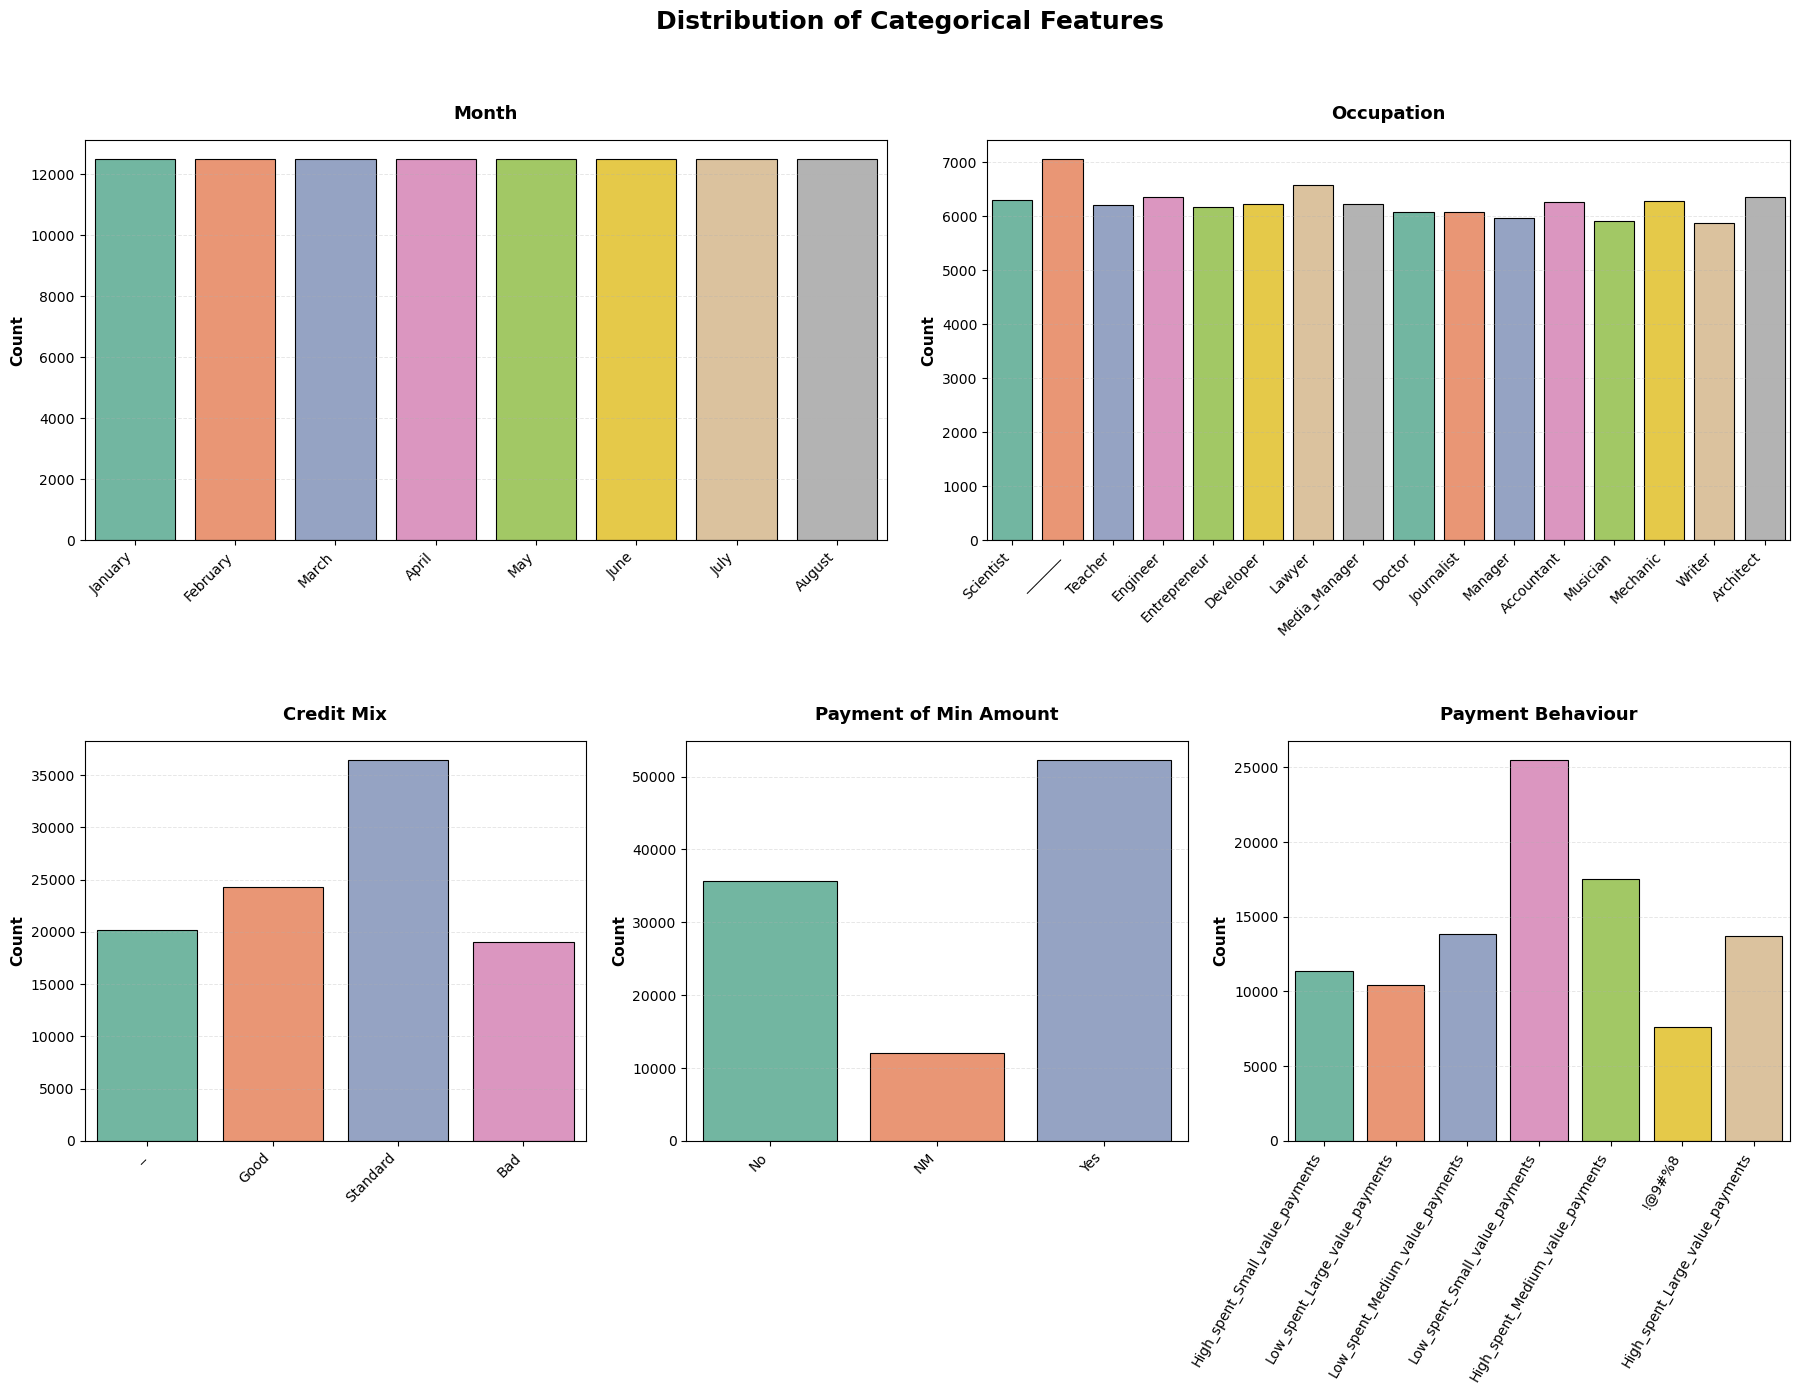

In [759]:
# Create a single figure with subplots for categorical variables
columns = ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

fig = plt.figure(figsize=(22, 13))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.5, wspace=0.5)

# Row 1: 2 plots centered
ax1 = fig.add_subplot(gs[0, 0:3])
ax2 = fig.add_subplot(gs[0, 3:6])

# Row 2: 3 plots
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])
ax5 = fig.add_subplot(gs[1, 4:6])

axes_list = [ax1, ax2, ax3, ax4, ax5]

fig.suptitle('Distribution of Categorical Features', fontsize=18, fontweight='bold', y=0.98)

for idx, col in enumerate(columns):
    ax = axes_list[idx]
    sns.countplot(data=df, x=col, ax=ax, palette='Set2', edgecolor='black', linewidth=0.8)
    ax.set_title(f'{col.replace("_", " ")}', fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('')
    ax.set_ylabel('Count', fontsize=11, fontweight='bold')
    
    # Special handling for Payment_Behaviour with long labels
    if col == 'Payment_Behaviour':
        ax.tick_params(axis='x', rotation=60, labelsize=10)
        for label in ax.get_xticklabels():
            label.set_ha('right')
            label.set_fontweight('medium')
    else:
        ax.tick_params(axis='x', rotation=45, labelsize=10)
        for label in ax.get_xticklabels():
            label.set_ha('right')
    
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 3.7 Numerical Features Distribution

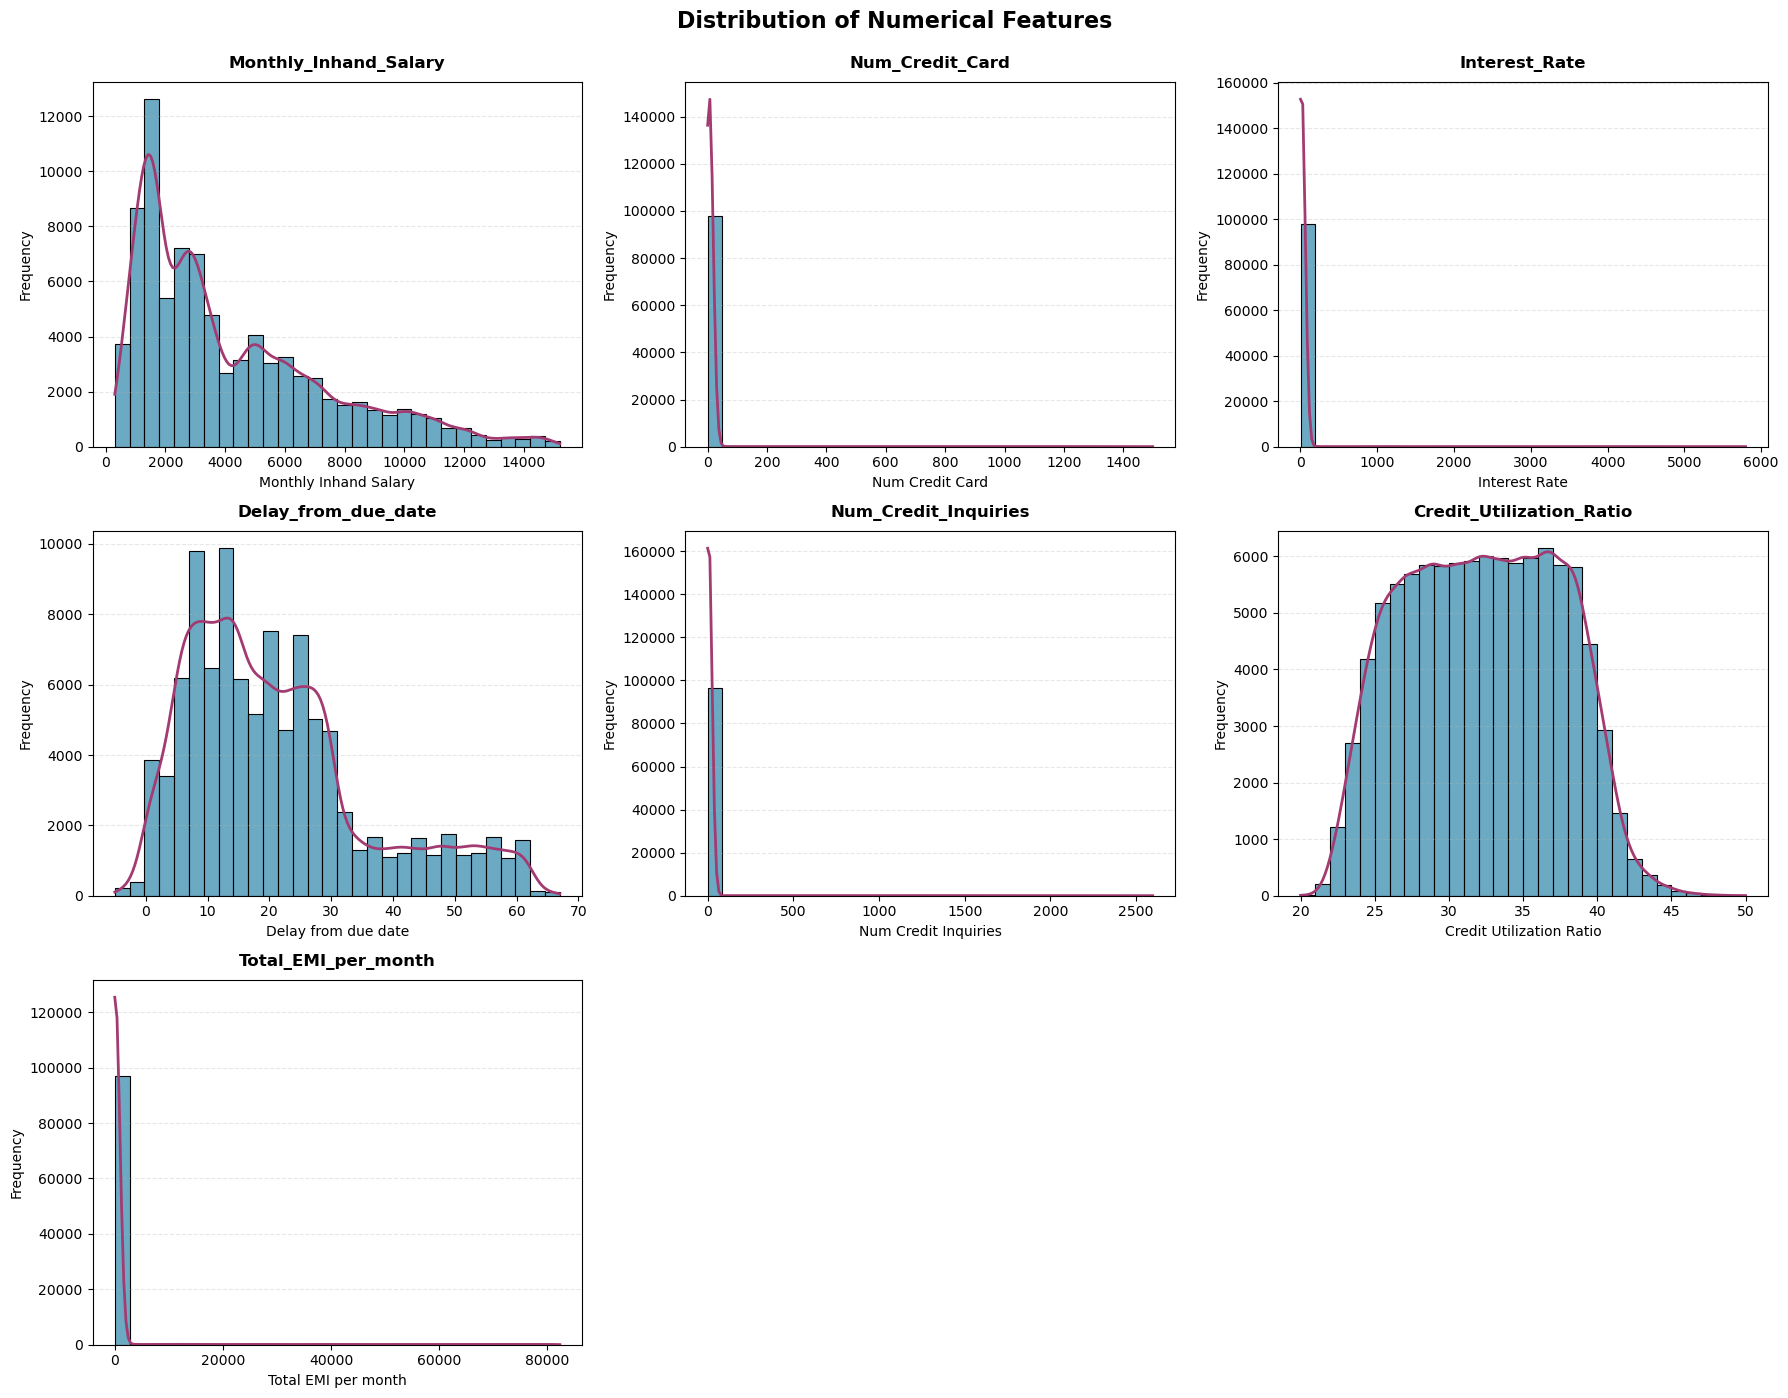

In [760]:
# Create a single figure with subplots for numerical variables
columns = ['Monthly_Inhand_Salary', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 
           'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Total_EMI_per_month']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=0.995)

axes = axes.flatten()

for idx, col in enumerate(columns):
    sns.histplot(data=df, x=col, kde=True, ax=axes[idx], color='#2E86AB', 
                 edgecolor='black', linewidth=0.8, bins=30, alpha=0.7)
    axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold', pad=10)
    axes[idx].set_xlabel(col.replace('_', ' '), fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    
    # Style KDE line
    for line in axes[idx].lines:
        line.set_color('#A23B72')
        line.set_linewidth(2)

# Hide the extra subplots
for idx in range(len(columns), 9):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 3.8 Type of Loan Analysis

In [761]:
# Display top 10 Type_of_Loan values
print("Type of Loan - Top 10 Values:")
df['Type_of_Loan'].value_counts().head(10)

Type of Loan - Top 10 Values:


Type of Loan - Top 10 Values:


Type_of_Loan
Not Specified                      1408
Credit-Builder Loan                1280
Personal Loan                      1272
Debt Consolidation Loan            1264
Student Loan                       1240
Payday Loan                        1200
Mortgage Loan                      1176
Auto Loan                          1152
Home Equity Loan                   1136
Personal Loan, and Student Loan     320
Name: count, dtype: int64

## 3.9 Initial Observations

**Key Findings from EDA:**
1. **ID, Name, SSN**: Not useful for prediction (should be dropped)
2. **Data Type Issues**: Age, Annual_Income, Num_of_Loan, Num_of_Delayed_Payment, Changed_Credit_Limit, Amount_invested_monthly, Outstanding_Debt, Monthly_Balance are numerical but stored as categorical (need fixing)
3. **Placeholder Values**: Occupation and Credit_Mix have "__" values that need replacement
4. **Data Quality Issues**:
   - Data contains outliers
   - Num_Credit_Card has zeros
   - Num_Bank_Accounts contains negative values
5. **Feature Engineering Needed**:
   - Type_of_Loan needs to be split into multiple binary columns
   - Credit_History_Age format needs conversion to months
   - Payment_of_Min_Amount has 'NM' values
   - Payment_Behaviour and Credit_Mix need cleaning
6. **Target Imbalance**: Credit Score distribution is imbalanced
7. **Missing Data**: Significant missing values across multiple columns

# === 4. DATA CLEANING ===

## 4.1 Drop Irrelevant Columns

In [762]:
# Drop ID, Name, and SSN columns (not useful for prediction)
cols_to_drop = ['ID', 'Name', 'SSN']
df.drop(cols_to_drop, axis=1, inplace=True)

print(f"Dropped columns: {cols_to_drop}")
print(f"New shape: {df.shape}")

Dropped columns: ['ID', 'Name', 'SSN']
New shape: (100000, 25)


## 4.2 Fix Data Type Issues

In [763]:
# Remove underscores from numerical columns stored as strings and convert to float
cols_to_fix = [
    'Age',
    'Annual_Income',
    'Num_of_Loan',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Outstanding_Debt',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

for col in cols_to_fix:
    df[col] = df[col].str.replace('_', '')
    try:
        df[col] = df[col].astype('float')
    except:
        continue

print("Fixed data types for numerical columns:")
df[cols_to_fix].info()

Fixed data types for numerical columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      100000 non-null  float64
 1   Annual_Income            100000 non-null  float64
 2   Num_of_Loan              100000 non-null  float64
 3   Num_of_Delayed_Payment   92998 non-null   float64
 4   Changed_Credit_Limit     100000 non-null  object 
 5   Outstanding_Debt         100000 non-null  float64
 6   Amount_invested_monthly  95521 non-null   float64
 7   Monthly_Balance          98800 non-null   float64
dtypes: float64(7), object(1)
memory usage: 6.1+ MB


In [764]:
# Fix Changed_Credit_Limit - replace empty strings with NaN
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].replace('', np.nan)
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].astype('float')

print("Fixed Changed_Credit_Limit column")

Fixed Changed_Credit_Limit column


In [765]:
# Verify fixes with descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,100000.0,1.106497e+02,6.862447e+02,-5.000000e+02,24.000000,33.000000,42.000000,8.698000e+03
Annual_Income,100000.0,1.764157e+05,1.429618e+06,7.005930e+03,19457.500000,37578.610000,72790.920000,2.419806e+07
Monthly_Inhand_Salary,84998.0,4.194171e+03,3.183686e+03,3.036454e+02,1625.568229,3093.745000,5957.448333,1.520463e+04
Num_Bank_Accounts,100000.0,1.709128e+01,1.174048e+02,-1.000000e+00,3.000000,6.000000,7.000000,1.798000e+03
Num_Credit_Card,100000.0,2.247443e+01,1.290574e+02,0.000000e+00,4.000000,5.000000,7.000000,1.499000e+03
Interest_Rate,100000.0,7.246604e+01,4.664226e+02,1.000000e+00,8.000000,13.000000,20.000000,5.797000e+03
Num_of_Loan,100000.0,3.009960e+00,6.264788e+01,-1.000000e+02,1.000000,3.000000,5.000000,1.496000e+03
Delay_from_due_date,100000.0,2.106878e+01,1.486010e+01,-5.000000e+00,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,92998.0,3.092334e+01,2.260319e+02,-3.000000e+00,9.000000,14.000000,18.000000,4.397000e+03
Changed_Credit_Limit,97909.0,1.038903e+01,6.789496e+00,-6.490000e+00,5.320000,9.400000,14.870000,3.697000e+01


## 4.3 Handle Negative Values and Invalid Entries

In [766]:
# Replace negative values with NaN (invalid entries)
columns_to_fix = ['Age', 'Num_Bank_Accounts', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit']

df[columns_to_fix] = df[columns_to_fix].applymap(lambda x: np.nan if x < 0 else x)

print("Replaced negative values with NaN")
print("\nDescriptive statistics after fixing:")
df[cols_to_fix].describe().T

Replaced negative values with NaN

Descriptive statistics after fixing:


Replaced negative values with NaN

Descriptive statistics after fixing:


,count,mean,std,min,25%,50%,75%,max
Age,99114.0,1.161084e+02,6.868613e+02,1.400000e+01,25.000000,33.000000,42.000000,8.698000e+03
Annual_Income,100000.0,1.764157e+05,1.429618e+06,7.005930e+03,19457.500000,37578.610000,72790.920000,2.419806e+07
Num_of_Loan,96124.0,7.163622e+00,6.031492e+01,0.000000e+00,2.000000,3.000000,5.000000,1.496000e+03
Num_of_Delayed_Payment,92354.0,3.115052e+01,2.268022e+02,0.000000e+00,9.000000,14.000000,18.000000,4.397000e+03
Changed_Credit_Limit,96323.0,1.059904e+01,6.639966e+00,0.000000e+00,5.570000,9.520000,15.010000,3.697000e+01
Outstanding_Debt,100000.0,1.426220e+03,1.155129e+03,2.300000e-01,566.072500,1166.155000,1945.962500,4.998070e+03
Amount_invested_monthly,95521.0,6.374130e+02,2.043319e+03,0.000000e+00,74.534002,135.925682,265.731733,1.000000e+04
Monthly_Balance,98800.0,-3.036437e+22,3.181295e+24,-3.333333e+26,270.092209,336.719190,470.220186,1.602041e+03


## 4.4 Initial Correlation Analysis

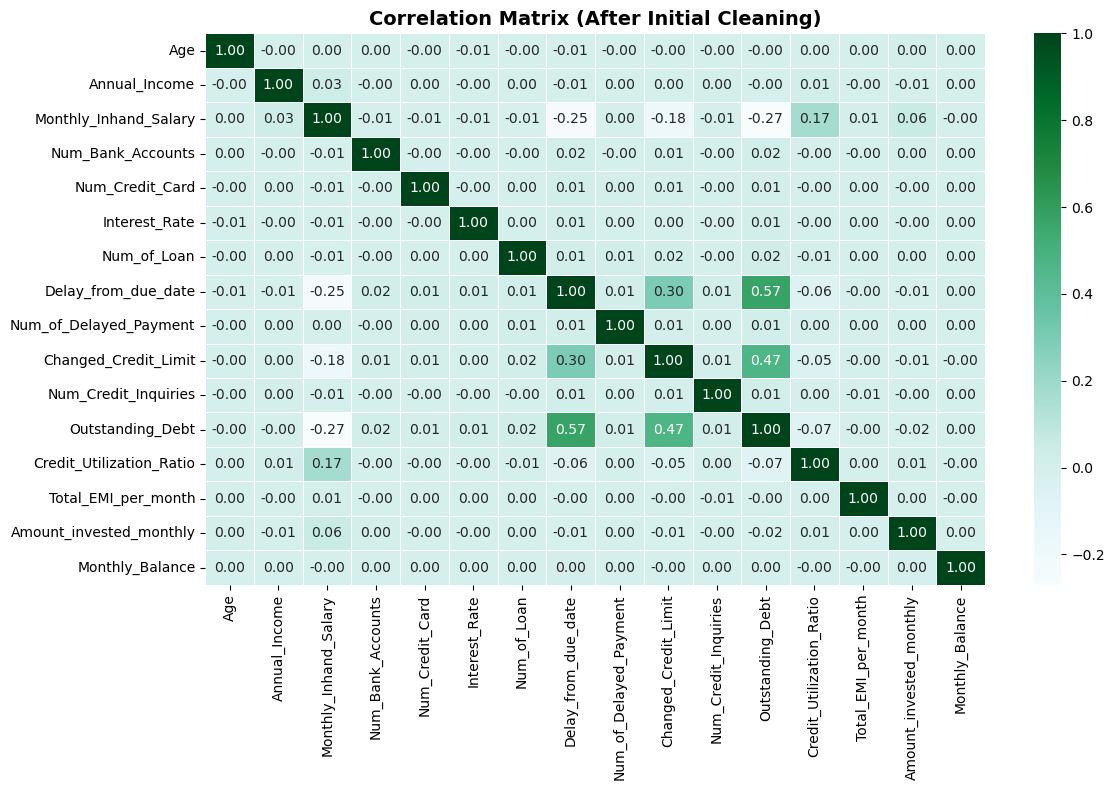

In [767]:
# Correlation matrix after initial cleaning
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='BuGn', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix (After Initial Cleaning)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.5 Categorical Data Examination

In [768]:
# Examine categorical features
data_categorical = df[df.select_dtypes(include=['object']).columns]
print("Categorical features:")
data_categorical.head()

Categorical features:


,Customer_ID,Month,Occupation,Type_of_Loan,Credit_Mix,Credit_History_Age,Payment_of_Min_Amount,Payment_Behaviour,Credit_Score
0,CUS_0xd40,January,Scientist,"Auto Loan, Credit-Builder Loan, Personal Loan,...",_,22 Years and 1 Months,No,High_spent_Small_value_payments,Good
1,CUS_0xd40,February,Scientist,"Auto Loan, Credit-Builder Loan, Personal Loan,...",Good,NaN,No,Low_spent_Large_value_payments,Good
2,CUS_0xd40,March,Scientist,"Auto Loan, Credit-Builder Loan, Personal Loan,...",Good,22 Years and 3 Months,No,Low_spent_Medium_value_payments,Good
3,CUS_0xd40,April,Scientist,"Auto Loan, Credit-Builder Loan, Personal Loan,...",Good,22 Years and 4 Months,No,Low_spent_Small_value_payments,Good
4,CUS_0xd40,May,Scientist,"Auto Loan, Credit-Builder Loan, Personal Loan,...",Good,22 Years and 5 Months,No,High_spent_Medium_value_payments,Good


In [769]:
# Value counts for all categorical columns
for i in df.select_dtypes(include='object').columns.tolist():
    print(f'\n{i} value counts:')
    print(df[i].value_counts())
    print('-' * 50)


Customer_ID value counts:
Customer_ID
CUS_0xd40     8
CUS_0x9bf4    8
CUS_0x5ae3    8
CUS_0xbe9a    8
CUS_0x4874    8
             ..
CUS_0x2eb4    8
CUS_0x7863    8
CUS_0x9d89    8
CUS_0xc045    8
CUS_0x942c    8
Name: count, Length: 12500, dtype: int64
--------------------------------------------------

Month value counts:
Month
January     12500
February    12500
March       12500
April       12500
May         12500
June        12500
July        12500
August      12500
Name: count, dtype: int64
--------------------------------------------------

Occupation value counts:
Occupation
_______          7062
Lawyer           6575
Architect        6355
Engineer         6350
Scientist        6299
Mechanic         6291
Accountant       6271
Developer        6235
Media_Manager    6232
Teacher          6215
Entrepreneur     6174
Doctor           6087
Journalist       6085
Manager          5973
Musician         5911
Writer           5885
Name: count, dtype: int64
------------------------------

## 4.6 Feature-Specific Cleaning

In [770]:
# Convert Credit_History_Age from "X Years and Y Months" to total months
def to_months(val):
    if pd.isnull(val):
        return val
    x = int(val.split(' ')[0])
    y = int(val.split(' ')[3])
    return x * 12 + y

df['Credit_History_Age'] = df['Credit_History_Age'].apply(lambda x: to_months(x)).astype(float)
print("Converted Credit_History_Age to months")

Converted Credit_History_Age to months


In [771]:
# Standardize Payment_of_Min_Amount: replace 'NM' with 'No'
df['Payment_of_Min_Amount'].replace('NM', 'No', inplace=True)
print("Standardized Payment_of_Min_Amount values")

Standardized Payment_of_Min_Amount values


In [772]:
# Replace placeholder values with NaN
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', np.nan)
df['Occupation'] = df['Occupation'].replace('_______', np.nan)
df['Credit_Mix'] = df['Credit_Mix'].replace('_', np.nan)

print("Replaced placeholder values with NaN in Payment_Behaviour, Occupation, and Credit_Mix")

Replaced placeholder values with NaN in Payment_Behaviour, Occupation, and Credit_Mix


In [773]:
# Transform Customer_ID from hexadecimal string to integer
df['Customer_ID'] = df['Customer_ID'].apply(lambda x: int(x[4:], 16))
print("Transformed Customer_ID from hexadecimal to integer")

Transformed Customer_ID from hexadecimal to integer


# === 5. MISSING VALUE TREATMENT ===

## 5.1 Post-Cleaning Missing Values Analysis

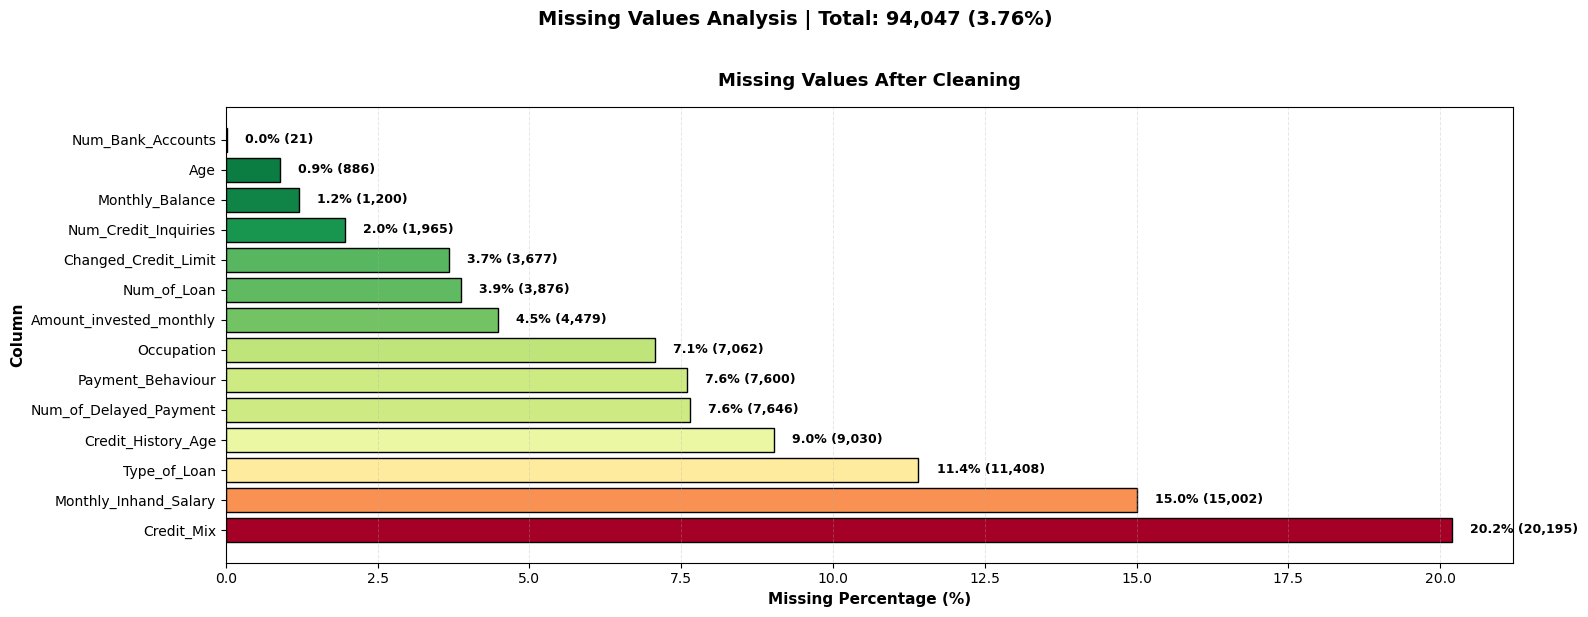


Columns with missing values: 14 out of 25


In [774]:
# Visualize missing values after cleaning
fig, ax1 = plt.subplots(1,1, figsize=(16, 6))

missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Count': missing_count,
    'Percentage': missing_percentage
})
missing_df = missing_df[missing_df['Count'] > 0].sort_values(by='Percentage', ascending=False)

colors_gradient = plt.cm.RdYlGn_r(missing_df['Percentage'] / missing_df['Percentage'].max())
bars = ax1.barh(missing_df['Column'], missing_df['Percentage'], color=colors_gradient, 
                edgecolor='black', linewidth=1)

ax1.set_xlabel('Missing Percentage (%)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Column', fontsize=11, fontweight='bold')
ax1.set_title('Missing Values After Cleaning', fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.7)

for i, (bar, pct, count) in enumerate(zip(bars, missing_df['Percentage'], missing_df['Count'])):
    width = bar.get_width()
    ax1.text(width + 0.3, bar.get_y() + bar.get_height()/2, 
             f'{pct:.1f}% ({int(count):,})',
             ha='left', va='center', fontsize=9, fontweight='bold')

total_missing = missing_count.sum()
total_cells = df.shape[0] * df.shape[1]
overall_pct = (total_missing / total_cells) * 100

fig.suptitle(f'Missing Values Analysis | Total: {int(total_missing):,} ({overall_pct:.2f}%)', 
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

print(f"\nColumns with missing values: {len(missing_df)} out of {df.shape[1]}")

In [775]:
# Check missing value counts
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

Missing values per column:
Age                          886
Occupation                  7062
Monthly_Inhand_Salary      15002
Num_Bank_Accounts             21
Num_of_Loan                 3876
Type_of_Loan               11408
Num_of_Delayed_Payment      7646
Changed_Credit_Limit        3677
Num_Credit_Inquiries        1965
Credit_Mix                 20195
Credit_History_Age          9030
Amount_invested_monthly     4479
Payment_Behaviour           7600
Monthly_Balance             1200
dtype: int64


## 5.2 Imputation Strategy for Categorical Features

In [776]:
# Function to fill categorical missing values
# Strategy: Use mode per Customer_ID, otherwise use global mode
def fill_na_cat(data, val):
    nan_idx = list(data[val][data[val].isnull()].index)
    
    for i in nan_idx:
        val_pred = data[val][data['Customer_ID'] == data.iloc[i]['Customer_ID']].mode()[0]
        if not pd.isna(val_pred):
            data.loc[i, val] = val_pred
        else:
            data.loc[i, val] = data[val].mode()[0]
    
    return list(data[val])

print("Categorical imputation function defined")

Categorical imputation function defined


In [777]:
# Identify categorical columns with missing values (exclude Type_of_Loan for special handling)
missing_cat_cols = set(missing_df['Column'].tolist()).intersection(df.select_dtypes(include='object').columns.tolist())
missing_cat_cols.discard('Type_of_Loan')

print(f"Categorical columns to impute: {missing_cat_cols}")

Categorical columns to impute: {'Occupation', 'Credit_Mix', 'Payment_Behaviour'}


In [778]:
# Fill categorical missing values
for col in missing_cat_cols:
    df[col] = fill_na_cat(df, col)
    print(f'Filled {col} column')

print("\nCategorical imputation complete!")

Filled Occupation column
Filled Credit_Mix column
Filled Credit_Mix column
Filled Payment_Behaviour column

Categorical imputation complete!
Filled Payment_Behaviour column

Categorical imputation complete!


## 5.3 Imputation Strategy for Numerical Features

In [779]:
# Function to fill numerical missing values
# Strategy: Use median per Customer_ID, otherwise use global median
def fill_na_num(data, val):
    nan_idx = list(data[val][data[val].isnull()].index)
    
    for i in nan_idx:
        val_pred = data[val][data['Customer_ID'] == data.iloc[i]['Customer_ID']].median()
        
        if not pd.isna(val_pred):
            data.loc[i, val] = val_pred
        else:
            data.loc[i, val] = data[val].median()
    
    return data[val]

print("Numerical imputation function defined")

Numerical imputation function defined


In [780]:
# Identify numerical columns with missing values
missing_num_cols = set(missing_df['Column'].tolist()).intersection(df.select_dtypes(exclude='object').columns.tolist())

print(f"Numerical columns to impute: {missing_num_cols}")

Numerical columns to impute: {'Num_of_Delayed_Payment', 'Num_Bank_Accounts', 'Num_Credit_Inquiries', 'Num_of_Loan', 'Changed_Credit_Limit', 'Amount_invested_monthly', 'Monthly_Inhand_Salary', 'Credit_History_Age', 'Monthly_Balance', 'Age'}


In [781]:
# Fill numerical missing values
for col in missing_num_cols:
    df[col] = fill_na_num(df, col)
    print(f'Filled {col} column')

print("\nNumerical imputation complete!")

Filled Num_of_Delayed_Payment column
Filled Num_Bank_Accounts column
Filled Num_Credit_Inquiries column
Filled Num_Credit_Inquiries column
Filled Num_of_Loan column
Filled Num_of_Loan column
Filled Changed_Credit_Limit column
Filled Changed_Credit_Limit column
Filled Amount_invested_monthly column
Filled Amount_invested_monthly column
Filled Monthly_Inhand_Salary column
Filled Monthly_Inhand_Salary column
Filled Credit_History_Age column
Filled Monthly_Balance column
Filled Credit_History_Age column
Filled Monthly_Balance column
Filled Age column

Numerical imputation complete!
Filled Age column

Numerical imputation complete!


## 5.4 Special Handling for Type_of_Loan

In [782]:
# Analyze Type_of_Loan structure and extract all loan types
loan_types = {}

for idx, row in df.iterrows():
    vals = row['Type_of_Loan']
    if pd.isnull(vals): 
        continue
    
    vals = vals.replace('and', '').split(', ')
    for val in vals:
        val = val.strip()
        loan_types[val] = loan_types.get(val, 0) + 1

print("Loan types found:")
for k, v in loan_types.items():
    print(f'{k}: {v}')

Loan types found:
Auto Loan: 37992
Credit-Builder Loan: 40440
Personal Loan: 38888
Home Equity Loan: 39104
Not Specified: 39616
Mortgage Loan: 38936
Student Loan: 38968
Debt Consolidation Loan: 38776
Payday Loan: 40568


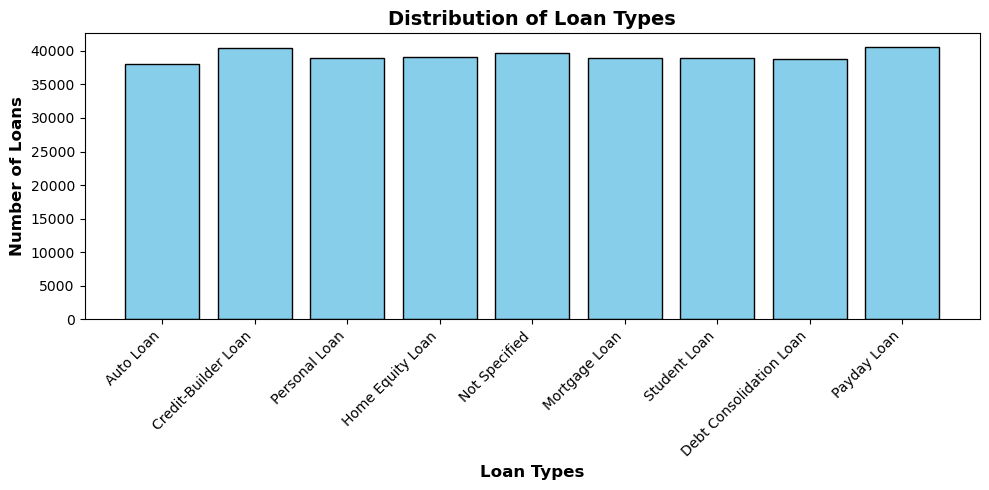

In [783]:
# Visualize loan types distribution
plt.figure(figsize=(10, 5))
plt.bar(loan_types.keys(), loan_types.values(), color='skyblue', edgecolor='black')
plt.xlabel('Loan Types', fontsize=12, fontweight='bold')
plt.ylabel('Number of Loans', fontsize=12, fontweight='bold')
plt.title('Distribution of Loan Types', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [784]:
# Check percentage of missing Type_of_Loan values
missing_pct = df['Type_of_Loan'].isna().sum() / len(df) * 100
print(f"Percentage of missing Type_of_Loan values: {missing_pct:.2f}%")

Percentage of missing Type_of_Loan values: 11.41%


## 5.5 Drop Remaining NaN Rows

In [785]:
# Drop rows with remaining NaN values (primarily Type_of_Loan)
shape_before = df.shape
df.dropna(inplace=True)
shape_after = df.shape

print(f"Shape before dropping NaN: {shape_before}")
print(f"Shape after dropping NaN: {shape_after}")
print(f"Rows dropped: {shape_before[0] - shape_after[0]}")

Shape before dropping NaN: (100000, 25)
Shape after dropping NaN: (88592, 25)
Rows dropped: 11408


## 5.6 Verification

In [786]:
# Verify no missing values remain
print("Remaining missing values:")
print(df.isna().sum().sum())
print("\nMissing value treatment complete! ✓")

Remaining missing values:
0

Missing value treatment complete! ✓


# === 6. FEATURE ENGINEERING ===

## 6.1 Type_of_Loan Expansion to Binary Columns

In [787]:
# Create binary columns for each loan type
col_map = {True: 1, False: 0}

for loan_type in list(loan_types.keys()):
    df[loan_type] = df['Type_of_Loan'].str.contains(loan_type).map(col_map)

print(f"Created {len(loan_types)} binary loan type columns")
df.info()

Created 9 binary loan type columns
<class 'pandas.core.frame.DataFrame'>
Index: 88592 entries, 0 to 99999
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               88592 non-null  int64  
 1   Month                     88592 non-null  object 
 2   Age                       88592 non-null  float64
 3   Occupation                88592 non-null  object 
 4   Annual_Income             88592 non-null  float64
 5   Monthly_Inhand_Salary     88592 non-null  float64
 6   Num_Bank_Accounts         88592 non-null  float64
 7   Num_Credit_Card           88592 non-null  int64  
 8   Interest_Rate             88592 non-null  int64  
 9   Num_of_Loan               88592 non-null  float64
 10  Type_of_Loan              88592 non-null  object 
 11  Delay_from_due_date       88592 non-null  int64  
 12  Num_of_Delayed_Payment    88592 non-null  float64
 13  Changed_Credit_Limit      88592

## 6.2 Drop Original Type_of_Loan and 'Not Specified'

In [788]:
# Drop the original Type_of_Loan column and 'Not Specified' column
df.drop(['Type_of_Loan', 'Not Specified'], axis=1, inplace=True)

print(f"Dropped Type_of_Loan and 'Not Specified' columns")
print(f"Current shape: {df.shape}")

Dropped Type_of_Loan and 'Not Specified' columns
Current shape: (88592, 32)


## 6.3 Reorder Columns (Move Target to End)

In [789]:
# Move Credit_Score to the end for consistency
y = df['Credit_Score']
df = df.drop('Credit_Score', axis=1)
df['Credit_Score'] = y

print("Moved Credit_Score to last column")
print(f"Final shape after feature engineering: {df.shape}")

Moved Credit_Score to last column
Final shape after feature engineering: (88592, 32)


# === 7. ADVANCED EDA & FEATURE ANALYSIS ===

## 7.1 Select Numerical Columns for Analysis

In [790]:
# Select numerical columns (excluding Customer_ID and loan type binary columns)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns[1:-8].tolist()

print(f"Number of numerical columns for analysis: {len(num_cols)}")
print(f"\nNumerical columns: {num_cols}")

Number of numerical columns for analysis: 17

Numerical columns: ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']


## 7.2 KDE Plots by Credit Score

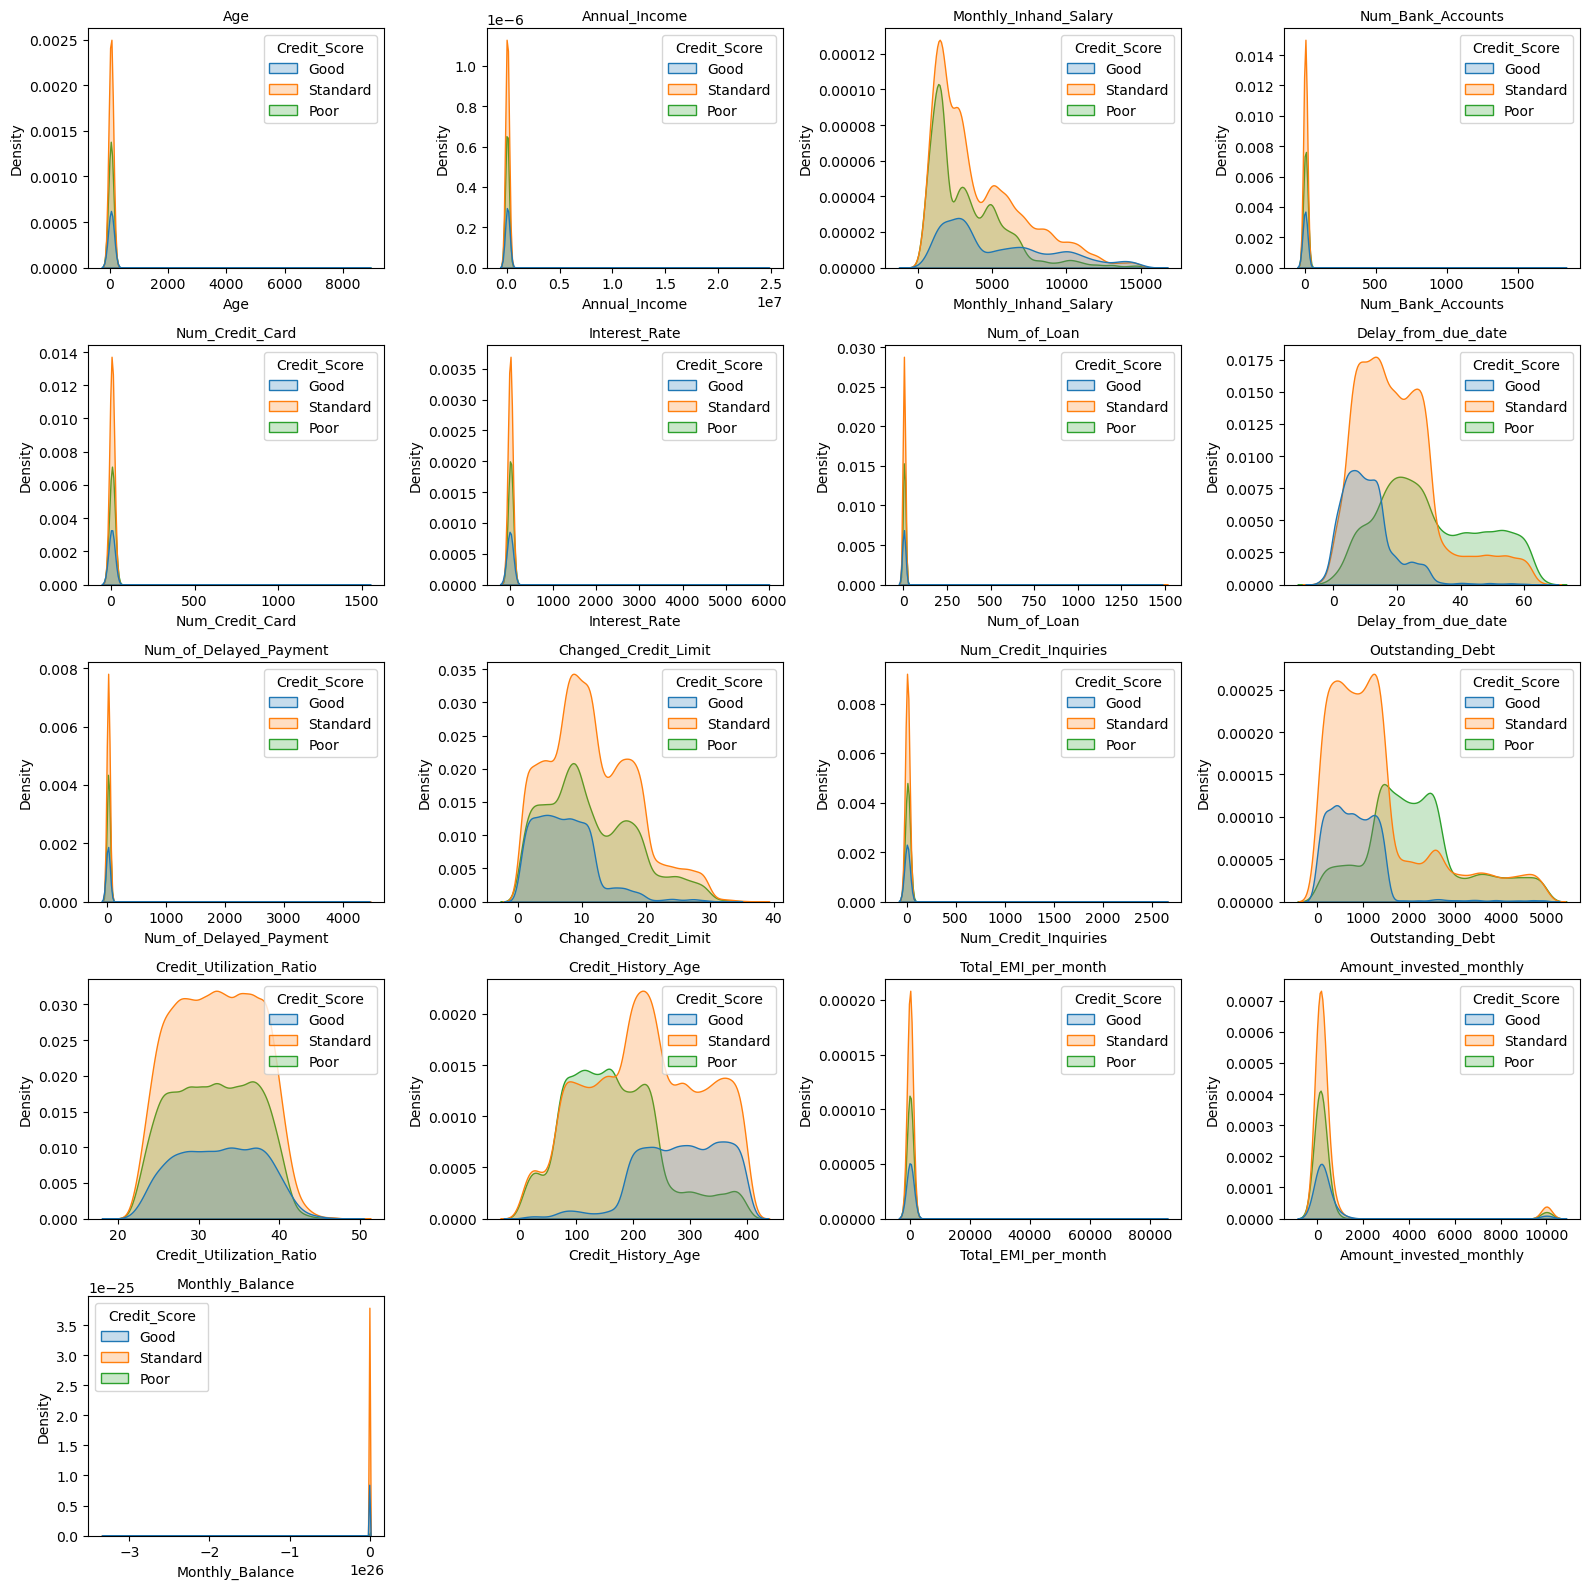

In [791]:
# KDE plots for numerical features colored by Credit Score
plt.figure(figsize=(16, 16))

for ax, col in enumerate(num_cols):
    plt.subplot(5, 4, ax + 1)
    plt.title(col, fontsize=10)
    sns.kdeplot(x=df[col], shade=True, hue=df['Credit_Score'])

plt.tight_layout()
plt.show()

## 7.3 Pairplot for Key Features

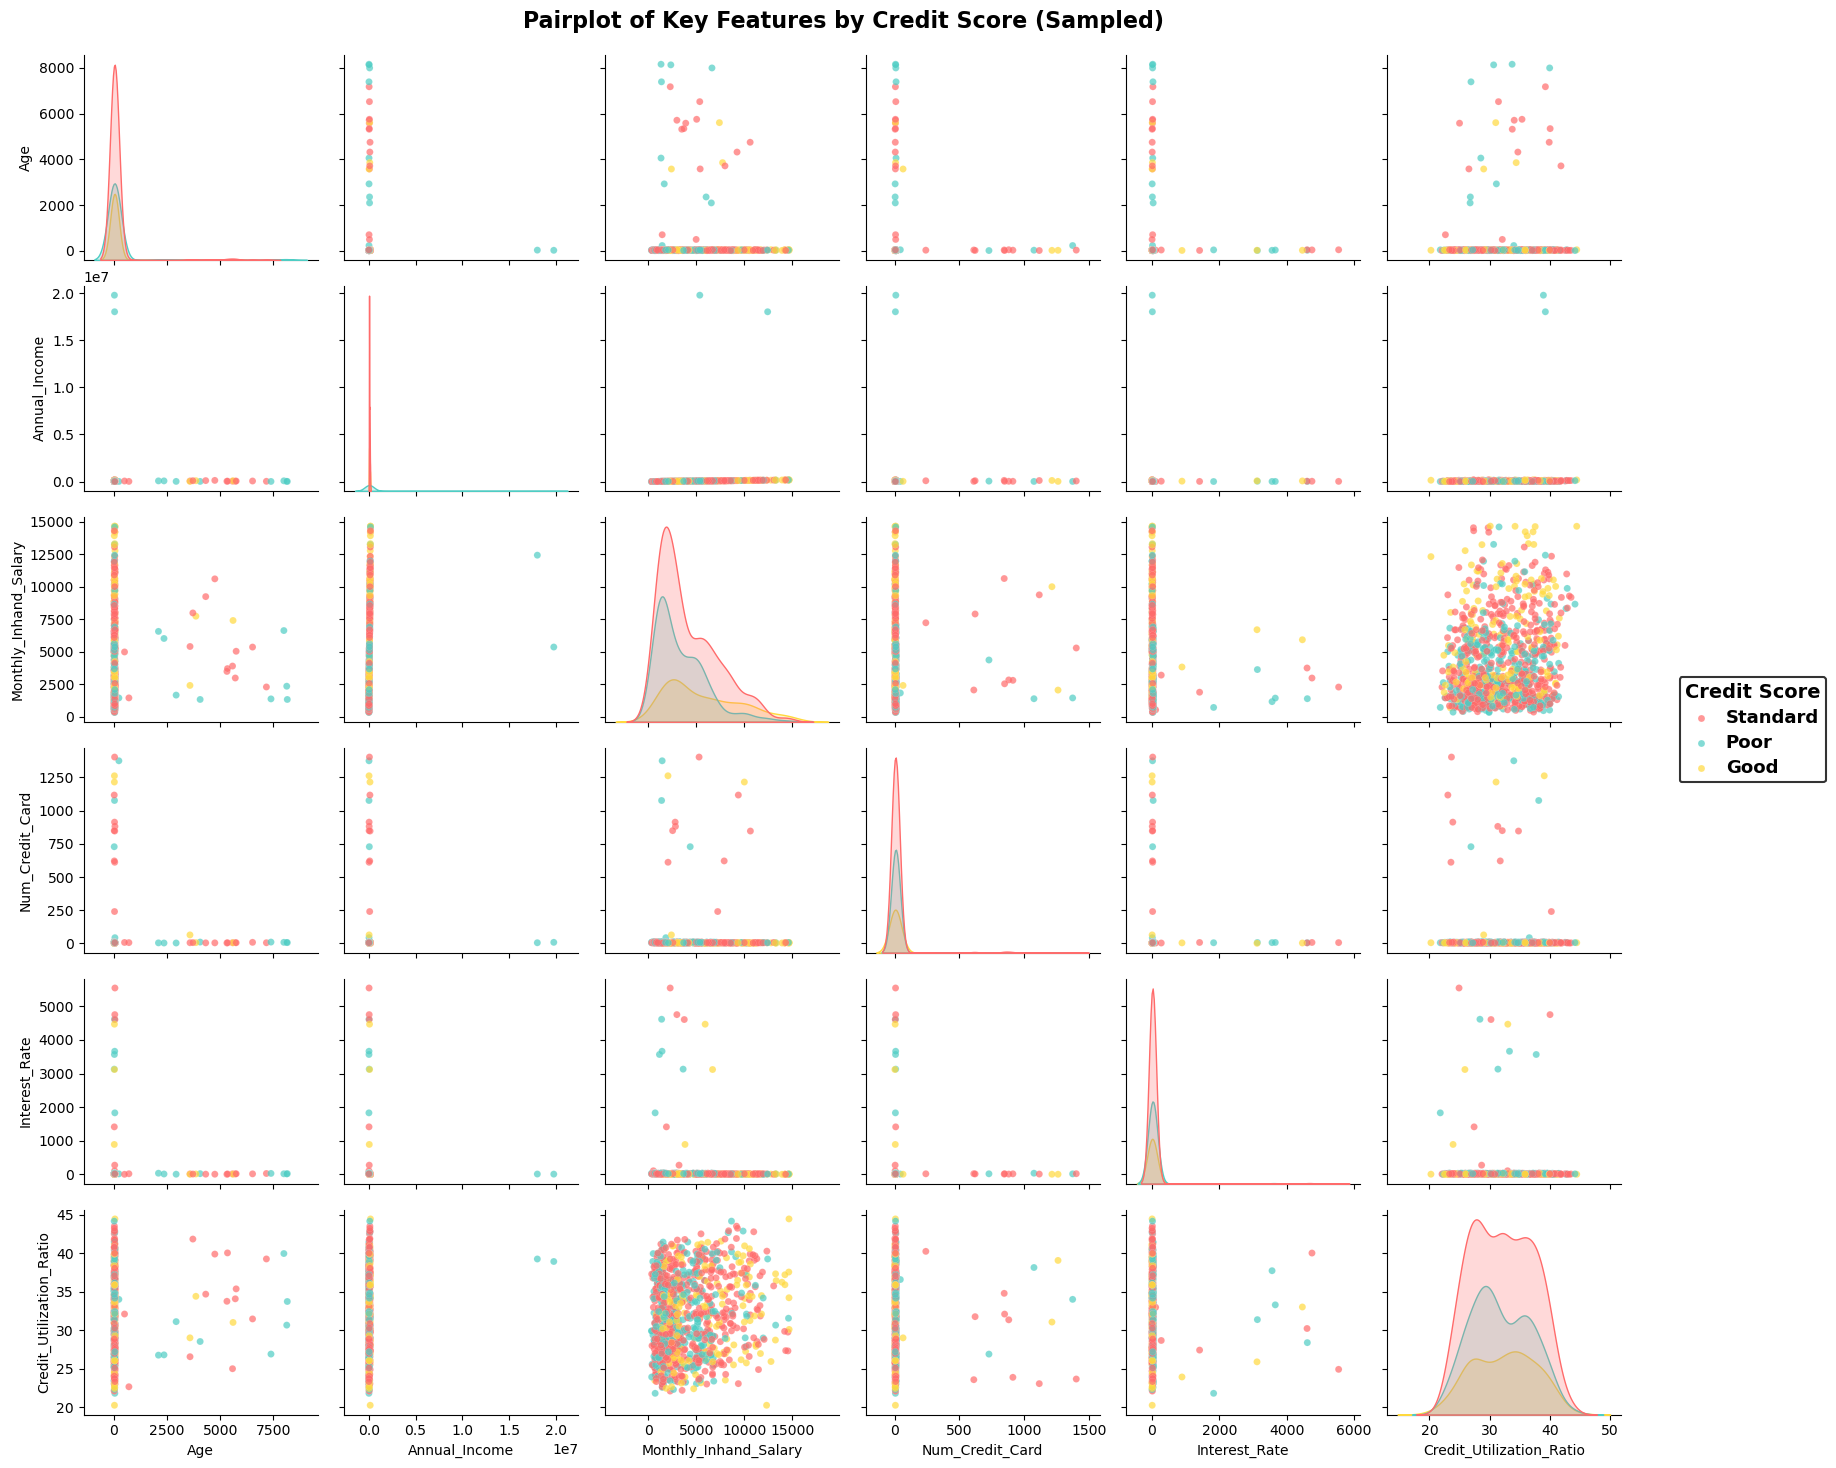


Pairplot generated successfully!
Features analyzed: 6
Target classes: ['Standard' 'Poor' 'Good']
Sample size used: 1000


In [ ]:
# Create pairplot for selected key features to visualize relationships
# Note: Using original Credit_Score values (Poor, Standard, Good) before encoding
key_features = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Credit_Card',
                'Interest_Rate', 'Credit_Utilization_Ratio', 'Credit_Score']

pairplot_df = df[key_features].dropna().copy()

# Sampling limits the number of rows to keep the plot performant on large datasets
sample_size = min(1000, len(pairplot_df))
pairplot_sample = pairplot_df.sample(n=sample_size, random_state=42)

# Use more vibrant colors for better visibility
vibrant_colors = ['#FF6B6B', '#4ECDC4', '#FFD93D']  # Bright Red, Cyan, Yellow

g = sns.pairplot(pairplot_sample, hue='Credit_Score', palette=vibrant_colors,
                 plot_kws={'alpha': 0.7, 's': 25, 'edgecolor': 'white', 'linewidth': 0.1}, 
                 diag_kind='kde', height=2.5, aspect=1)

# Move legend outside and customize for better visibility
g._legend.remove()  # Remove default legend
g.add_legend(title='Credit Score', bbox_to_anchor=(0.98, 0.5), loc='center left')
g._legend.set_frame_on(True)
g._legend.get_frame().set_facecolor('white')
g._legend.get_frame().set_edgecolor('black')
g._legend.get_frame().set_linewidth(1.5)

# Make legend text larger and bold
for text in g._legend.texts:
    text.set_fontsize(13)
    text.set_fontweight('bold')

# Make legend title bold and larger
g._legend.get_title().set_fontsize(14)
g._legend.get_title().set_fontweight('bold')

g.figure.subplots_adjust(top=0.95, right=0.95)
g.figure.suptitle('Pairplot of Key Features by Credit Score (Sampled)', y=0.98,
               fontsize=16, fontweight='bold')
plt.show()

print("\nPairplot generated successfully!")
print(f"Features analyzed: {len(key_features) - 1}")
print(f"Target classes: {pairplot_sample['Credit_Score'].unique()}")
print(f"Sample size used: {sample_size}")

## 7.5 Chi-Square Tests for Categorical Independence

In [793]:
# Chi-square test function
def chi_square_test(data, col1, col2='Credit_Score'):
    occ = data[[col1, col2]]
    table = pd.crosstab(index=occ[col1], columns=occ[col2])
    t, p, sd, expected = stats.chi2_contingency(table)
    return t, p

print("Chi-square test function defined")

Chi-square test function defined


In [794]:
# Prepare test dataframe
q_test_cols = ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
test_df = df[q_test_cols].copy()
test_df['Credit_Score'] = df['Credit_Score']

print("Test dataframe prepared")
test_df.head()

NameError: name 'X_train_raw' is not defined

In [ ]:
# Perform chi-square tests for all categorical variables
cols, values, p_values = [], [], []

for col in test_df.columns[:-1].tolist():
    cols.append(col)
    t, p = chi_square_test(test_df, col)
    values.append(round(t, 2))
    p_values.append(round(p, 2))

chi_df = pd.DataFrame({
    'Variable': cols,
    'Chi2_Value': values,
    'P_value': p_values
})

chi_df = chi_df.sort_values(by='Chi2_Value', ascending=False)
chi_df.style.bar('Chi2_Value').background_gradient('Blues', subset='Chi2_Value')

## 7.6 ANOVA Tests for Numerical Features

In [ ]:
# Drop features with low chi-square values before ANOVA (Month and Occupation)
df.drop(['Month', 'Occupation'], axis=1, inplace=True)

print("Dropped Month and Occupation based on chi-square test results")
print(f"New shape: {df.shape}")

In [ ]:
# Select numeric features for ANOVA testing
df_numeric = df.select_dtypes(include=['int', 'float'])

# Remove loan type binary columns for this analysis
cols_to_drop_temp = [
    'Auto Loan', 'Credit-Builder Loan', 'Personal Loan',
    'Home Equity Loan', 'Mortgage Loan', 'Student Loan',
    'Debt Consolidation Loan', 'Payday Loan'
]

df_numeric_test = df_numeric.drop(cols_to_drop_temp, axis=1)

# Add Credit_Score column which is required for the boxplots and ANOVA grouping
df_numeric_test['Credit_Score'] = df['Credit_Score']

print(f"Numerical columns for ANOVA: {len(df_numeric_test.columns)}")
print(df_numeric_test.columns.tolist())

In [ ]:
# ANOVA test function using Welch's ANOVA
def anova_test(data, col1, col2='Credit_Score'):
    df_test = data[[col1, col2]]
    df_melted = pd.melt(df_test, id_vars=col2, var_name=col1, value_name='value')
    test = pg.welch_anova(data=df_melted, dv='value', between=col2)
    return test

print("ANOVA test function defined")

In [ ]:
# Perform ANOVA tests for all numerical variables
cols, values, p_values = [], [], []

for col in df_numeric_test.columns[:-1]:
    cols.append(col)
    test = anova_test(df, col)
    values.append(round(float(test['F'].values), 2))
    p_values.append(round(float(test['p-unc'].values), 2))

anova_df = pd.DataFrame({
    'Variable': cols,
    'F_Value': values,
    'P_value': p_values
})

anova_df = anova_df.sort_values(by='F_Value', ascending=False)
anova_df.style.bar('F_Value').background_gradient('Blues', subset='F_Value')

In [ ]:
# Drop features with lowest ANOVA F-values (bottom 3)
cols_to_drop = anova_df['Variable'][-3:].tolist()
df.drop(cols_to_drop, axis=1, inplace=True)

print(f"Dropped features with low ANOVA scores: {cols_to_drop}")
print(f"New shape: {df.shape}")

In [ ]:
# Display final columns after feature selection
print("Final columns after statistical feature selection:")
print(df.columns.tolist())

# === 8. OUTLIER DETECTION & TREATMENT ===

## 8.1 Define Outlier Detection Functions

In [ ]:
# Define outlier detection functions using IQR method
def outlier_thresholds(data, col_name):
    Q1 = data[col_name].quantile(0.25)
    Q3 = data[col_name].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    return lower_limit, upper_limit

def check_outlier(data, col_name):
    lower_limit, upper_limit = outlier_thresholds(data, col_name)
    
    outliers = data[(data[col_name] > upper_limit) | (data[col_name] < lower_limit)]
    percentage_outliers = (len(outliers) / len(data)) * 100
    
    return outliers.any(axis=None), round(percentage_outliers, 2)

print("Outlier detection functions defined")

## 8.2 Outlier Percentage Analysis

In [ ]:
# Update num_cols after feature selection
num_cols = df.select_dtypes(include=['int64', 'float64']).columns[1:-8].tolist()

# Identify outliers in all numerical columns
outlier_rows = []

for col in num_cols:
    has_outliers, percentage = check_outlier(df, col)
    outlier_rows.append({
        'Column': col,
        'Has_Outliers': has_outliers,
        'Percentage': percentage
    })

outlier_results = pd.DataFrame(outlier_rows)
outlier_results = outlier_results[outlier_results['Has_Outliers']]
outlier_results = outlier_results[outlier_results['Percentage'] > 1]
outlier_results = outlier_results.sort_values(by='Percentage')

print("Outlier Analysis Results:")
outlier_results

In [ ]:
# Visualize outlier percentages
plt.figure(figsize=(10, 8))
bars = plt.barh(outlier_results['Column'], outlier_results['Percentage'], 
                color='skyblue', edgecolor='black')
plt.xlabel('Percentage of Outliers', fontsize=12, fontweight='bold')
plt.ylabel('Column', fontsize=12, fontweight='bold')
plt.title('Percentage of Outliers in Each Column', fontsize=14, fontweight='bold')
plt.xticks(np.arange(0, outlier_results['Percentage'].max() + 3, 3))

for bar, label in zip(bars, outlier_results['Percentage']):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, 
             f'{label:.2f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 8.3 Boxplot Visualization (Before Treatment)

In [ ]:
# Boxplots for each numerical feature by Credit Score (BEFORE outlier treatment)
for ax, col in enumerate(num_cols):
    plt.figure(figsize=(16, 2), dpi=80)
    sns.boxplot(x=df[col], y=df['Credit_Score'], data=df, orient='h')
    plt.title(f'{col} - Before Outlier Treatment', fontweight='bold')
    plt.show()

## 8.4 Outlier Treatment (Capping)

In [ ]:
# Function to replace outliers with threshold values (capping)
def replace_with_thresholds(data, col):
    lower_limit, upper_limit = outlier_thresholds(data, col)
    
    data.loc[(data[col] < lower_limit), col] = lower_limit
    data.loc[(data[col] > upper_limit), col] = upper_limit

# Apply outlier capping to all numerical columns
for col in num_cols:
    replace_with_thresholds(df, col)

print("Outlier treatment complete - all outliers capped at IQR boundaries")

## 8.5 Boxplot Visualization (After Treatment)

In [ ]:
# Boxplots for each numerical feature by Credit Score (AFTER outlier treatment)
for ax, col in enumerate(num_cols):
    plt.figure(figsize=(16, 2), dpi=80)
    sns.boxplot(x=df[col], y=df['Credit_Score'], data=df, orient='h')
    plt.title(f'{col} - After Outlier Treatment', fontweight='bold')
    plt.show()

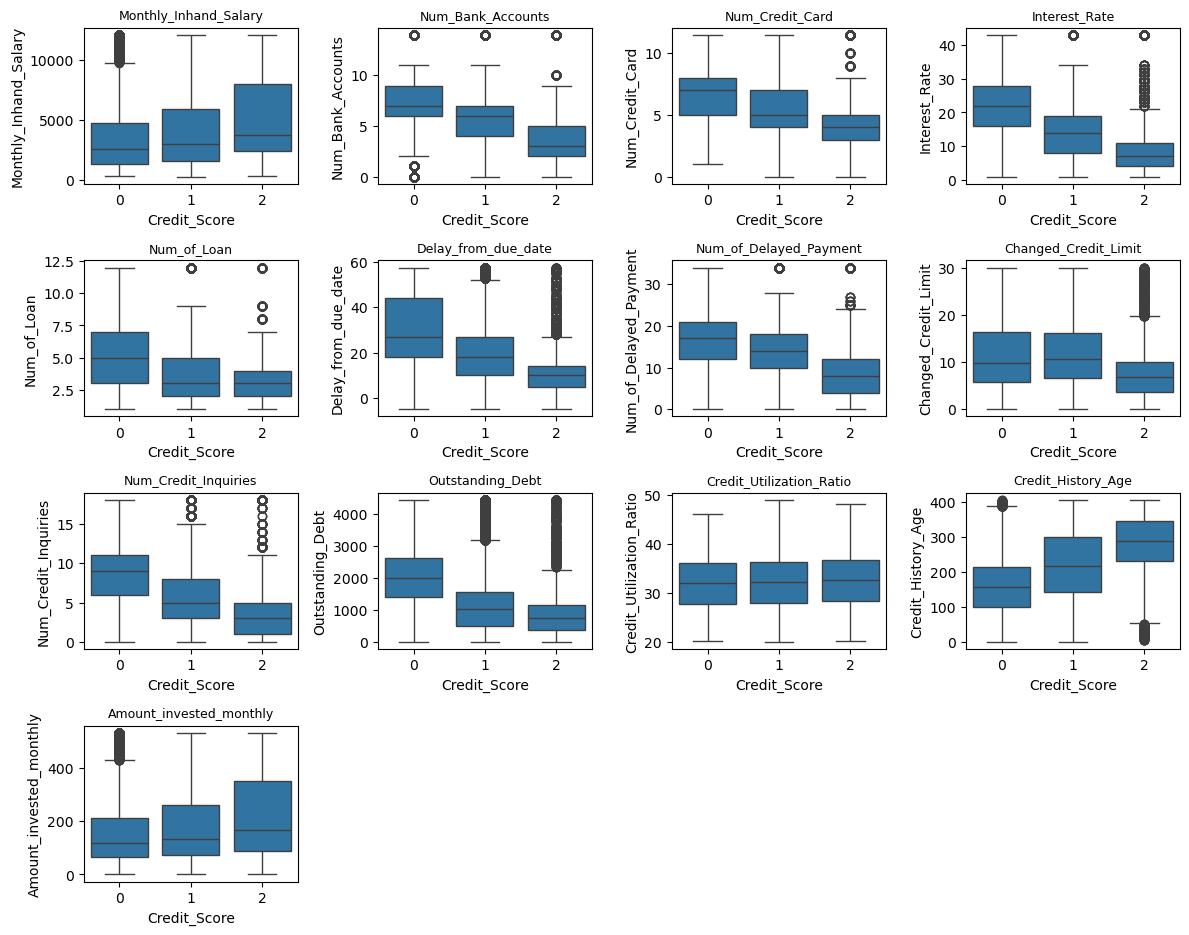

Multi-panel boxplot visualization complete - data shown AFTER outlier treatment


In [732]:
# Multi-panel boxplot visualization with encoded Credit_Score
# This shows the data state AFTER outlier treatment with proper ordering

# Create a temporary dataframe with encoded Credit_Score for visualization
df_temp = df.copy()
temp_label_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
df_temp['Credit_Score'] = df_temp['Credit_Score'].map(temp_label_map)

# Select numeric columns (excluding Customer_ID and loan type binary columns)
df_numeric_vis = df_temp.select_dtypes(include=['int', 'float'])

# Remove loan type binary columns
cols_to_drop_vis = [
    'Auto Loan', 'Credit-Builder Loan', 'Personal Loan',
    'Home Equity Loan', 'Mortgage Loan', 'Student Loan',
    'Debt Consolidation Loan', 'Payday Loan'
]
df_numeric_vis = df_numeric_vis.drop(cols_to_drop_vis, axis=1)

plt.figure(figsize=(12, 16))

for ax, col in enumerate(df_numeric_vis.columns[2:-1]):
    plt.subplot(7, 4, ax + 1)
    plt.title(col, fontsize=9)
    # Use order parameter to ensure Poor (0), Standard (1), Good (2) ordering
    sns.boxplot(x='Credit_Score', y=col, data=df_numeric_vis, order=[0, 1, 2])

plt.tight_layout()
plt.show()

print("Multi-panel boxplot visualization complete - data shown AFTER outlier treatment")

## 8.6 Distribution Comparison (Before/After)

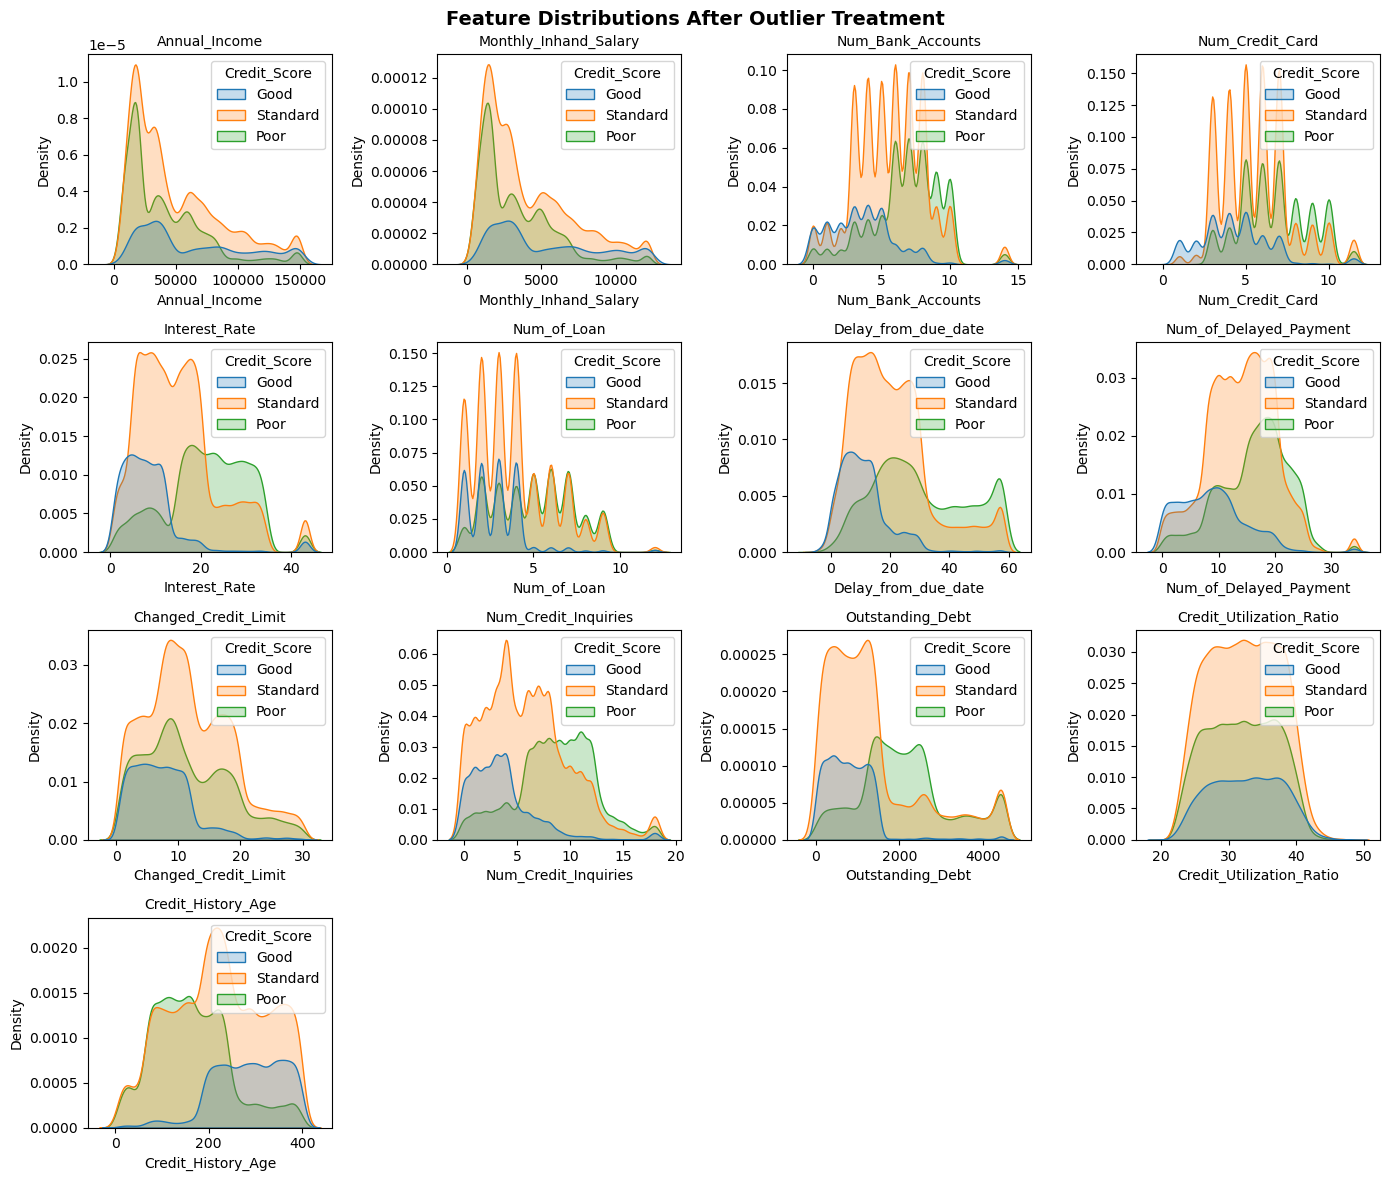

In [733]:
# KDE plots showing distribution after outlier treatment
plt.figure(figsize=(14, 12))

for ax, col in enumerate(num_cols[:-1]):
    plt.subplot(4, 4, ax + 1)
    plt.title(col, fontsize=10)
    sns.kdeplot(x=df[col], shade=True, hue=df['Credit_Score'])

plt.suptitle('Feature Distributions After Outlier Treatment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# === 9. FEATURE ENCODING ===

## 9.1 Target Variable Encoding

In [ ]:
# Encode Credit_Score: Poor=0, Standard=1, Good=2
label_map = {
    'Poor': 0,
    'Standard': 1,
    'Good': 2
}

df['Credit_Score'] = df['Credit_Score'].map(label_map)

print("Credit Score encoding:")
print(df['Credit_Score'].value_counts().sort_index())

## 9.2 Separate Features and Target

## 9.1b Visualize Categorical Features vs Encoded Target

In [ ]:
# Visualize relationship between categorical features and Credit Score (now numeric)
# Y-axis shows the mean Credit Score value (0=Poor, 1=Standard, 2=Good)
cat_cols = df.select_dtypes(include='object').columns.tolist()

if len(cat_cols) > 0:
    plt.figure(figsize=(20, 6))
    
    for i, col in enumerate(cat_cols, start=1):
        plt.subplot(1, len(cat_cols), i)
        g = sns.barplot(x=col, y='Credit_Score', data=df, errorbar=None)
        g.set_ylabel('Mean Credit Score (0=Poor, 1=Std, 2=Good)')
        g.set_xlabel(col)
        g.set_xticklabels(g.get_xticklabels(), rotation=90)
    
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns remaining at this stage.")

In [ ]:
# Separate features (X) and target (y)
features = df.drop('Credit_Score', axis=1)
label = df['Credit_Score']

print(f"Features shape: {features.shape}")
print(f"Label shape: {label.shape}")
print(f"\nLabel distribution:")
print(label.value_counts().sort_index())

## 9.3 Encode Categorical Features

In [ ]:
# Check remaining categorical columns
cat_col = features.select_dtypes(include='object').columns.tolist()

print(f"Remaining categorical columns: {cat_col}")
for col in cat_col:
    print(f"\n{col} value counts:")
    print(features[col].value_counts())

In [ ]:
# Ordinal encoding for Credit_Mix (Bad=0, Standard=1, Good=2)
cred_mix = {
    'Bad': 0,
    'Standard': 1,
    'Good': 2
}

features['Credit_Mix'] = features['Credit_Mix'].map(cred_mix)

# Binary encoding for Payment_of_Min_Amount (No=0, Yes=1)
min_pay = {
    'No': 0,
    'Yes': 1,
}

features['Payment_of_Min_Amount'] = features['Payment_of_Min_Amount'].map(min_pay)

print("Ordinal encoding complete for Credit_Mix and Payment_of_Min_Amount")

In [ ]:
# One-hot encoding for Payment_Behaviour (drop_first to avoid multicollinearity)
features = pd.get_dummies(features, columns=['Payment_Behaviour'], drop_first=True, dtype=int)

print(f"One-hot encoding complete")
print(f"New features shape: {features.shape}")

## 9.4 Data Type Optimization

In [ ]:
# Convert float columns that contain only integers to int type
float_cols_with_integers = df.select_dtypes(include='float').apply(
    lambda col: col.apply(lambda x: x.is_integer())).all()
float_cols_to_convert = float_cols_with_integers[float_cols_with_integers].index

features[float_cols_to_convert] = features[float_cols_to_convert].astype(int)

print(f"Converted {len(float_cols_to_convert)} float columns to int")

In [ ]:
#  Credit_History_Age to int
features['Credit_History_Age'] = features['Credit_History_Age'].astype(int)


## 9.5 Final Feature Overview

In [ ]:
# Display features info
print("Features Information:")
features.info()

print("\nFeatures sample:")
features.head()

## 9.6 Post-Encoding Correlation Matrix

In [ ]:
# Create final correlation matrix with all encoded features
final_df = features.copy()
final_df['Credit_Score'] = label

corr_matrix = final_df.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, cmap='BuGn', fmt='.2f', linewidths=.5, annot_kws={'size': 8})
plt.title('Final Correlation Matrix (Post-Encoding)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# === 10. PREPROCESSING FOR MODELING ===

## 10.1 Feature-Target Split Verification

In [ ]:
# Verify features and target are properly separated
print("="*60)
print("FEATURE-TARGET SPLIT VERIFICATION")
print("="*60)

print(f"\nFeatures (X) shape: {features.shape}")
print(f"Target (y) shape: {label.shape}")

print(f"\nNumber of features: {features.shape[1]}")
print(f"Number of samples: {features.shape[0]}")

print(f"\nFeatures data types:")
print(features.dtypes.value_counts())

print(f"\nTarget distribution:")
print(label.value_counts().sort_index())
print(f"\nTarget distribution (%):")
print(label.value_counts(normalize=True).sort_index() * 100)

## 10.2 Train-Test Split (Stratified)

In [745]:
# Split data into training and testing sets (80-20 split with stratification)
X_train, X_test, y_train, y_test = train_test_split(
    features, 
    label, 
    test_size=0.2, 
    random_state=42, 
    stratify=label
)

print("="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

print(f"\nTraining set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(features)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(features)*100:.1f}%)")

print(f"\nTraining set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing set shape: X_test={X_test.shape}, y_test={y_test.shape}")

print(f"\nTraining set class distribution:")
print(y_train.value_counts().sort_index())
print(f"\nTesting set class distribution:")
print(y_test.value_counts().sort_index())

TRAIN-TEST SPLIT

Training set size: 70873 samples (80.0%)
Testing set size: 17719 samples (20.0%)

Training set shape: X_train=(70873, 30), y_train=(70873,)
Testing set shape: X_test=(17719, 30), y_test=(17719,)

Training set class distribution:
Credit_Score
0    22129
1    37237
2    11507
Name: count, dtype: int64

Testing set class distribution:
Credit_Score
0    5533
1    9309
2    2877
Name: count, dtype: int64


## 10.3 Feature Scaling (RobustScaler)

In [ ]:
# Identify numerical columns for scaling (exclude binary columns)
# Binary columns: Credit_Mix, Payment_of_Min_Amount, Payment_Behaviour dummies, Loan types
binary_cols = ['Credit_Mix', 'Payment_of_Min_Amount'] + \
              [col for col in X_train.columns if col.startswith('Payment_Behaviour_')] + \
              ['Auto Loan', 'Credit-Builder Loan', 'Personal Loan', 
               'Home Equity Loan', 'Mortgage Loan', 'Student Loan',
               'Debt Consolidation Loan', 'Payday Loan']

# Get numerical columns that need scaling
numerical_cols = [col for col in X_train.columns if col not in binary_cols]

print(f"Columns to scale: {len(numerical_cols)}")
print(f"Binary columns (not scaled): {len(binary_cols)}")

# Initialize RobustScaler (robust to outliers)
scaler = RobustScaler()

# Fit scaler on training data and transform both train and test sets
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("\n" + "="*60)
print("FEATURE SCALING COMPLETE")
print("="*60)
print(f"\nScaled {len(numerical_cols)} numerical features using RobustScaler")
print(f"Training set: {X_train_scaled.shape}")
print(f"Testing set: {X_test_scaled.shape}")

## 10.4 Handle Class Imbalance with SMOTE

In [ ]:
# Apply SMOTE to balance classes (on training set only)
print("="*60)
print("CLASS IMBALANCE HANDLING WITH SMOTE")
print("="*60)

print("\nBefore SMOTE:")
print(f"Training set size: {X_train_scaled.shape[0]}")
print("Class distribution:")
print(y_train.value_counts().sort_index())

# Initialize SMOTE
smote = SMOTE(random_state=42, sampling_strategy='auto')

# Apply SMOTE to training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE:")
print(f"Training set size: {X_train_resampled.shape[0]}")
print("Class distribution:")
print(pd.Series(y_train_resampled).value_counts().sort_index())

print("\n" + "="*60)
print("SMOTE RESAMPLING COMPLETE")
print("="*60)

## 10.5 Final Dataset Verification

In [ ]:
# Final verification and summary
print("="*70)
print(" " * 15 + "FINAL DATASET SUMMARY")
print("="*70)

print("\n📊 DATASET SHAPES:")
print(f"   Training Features (Resampled):  {X_train_resampled.shape}")
print(f"   Training Labels (Resampled):    {y_train_resampled.shape}")
print(f"   Testing Features:               {X_test_scaled.shape}")
print(f"   Testing Labels:                 {y_test.shape}")

print("\n📈 CLASS DISTRIBUTION:")
print("\n   Training Set (After SMOTE):")
train_dist = pd.Series(y_train_resampled).value_counts().sort_index()
for idx, count in train_dist.items():
    class_name = ['Poor', 'Standard', 'Good'][idx]
    pct = count / len(y_train_resampled) * 100
    print(f"      {class_name:10s}: {count:6d} ({pct:5.2f}%)")

print("\n   Testing Set (Original Distribution):")
test_dist = y_test.value_counts().sort_index()
for idx, count in test_dist.items():
    class_name = ['Poor', 'Standard', 'Good'][idx]
    pct = count / len(y_test) * 100
    print(f"      {class_name:10s}: {count:6d} ({pct:5.2f}%)")

print("\n✅ DATA PREPROCESSING COMPLETE!")
print("="*70)
print("\n📦 Model-Ready Datasets:")
print("   • X_train_resampled: Scaled & balanced training features")
print("   • y_train_resampled: Balanced training labels")
print("   • X_test_scaled: Scaled testing features")
print("   • y_test: Original testing labels")
print("\n🚀 Ready for Machine Learning Model Training!")
print("="*70)